In [1]:
%load_ext autoreload
%autoreload 2
import pickle
import csv
import numpy as np

In [2]:
#with open('../Data/dataset/mesh.csv', 'r') as file:
mesh = np.loadtxt('../Data/MP_data/mesh.csv', delimiter=',')

In [3]:
import matplotlib.pyplot as plt

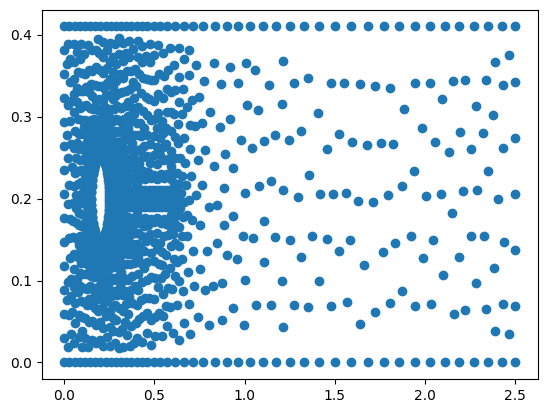

In [4]:
plt.scatter(mesh[0,:], mesh[1,:])
plt.show()

In [5]:
print(mesh.shape)

(2, 1317)


In [6]:
with open('../Data/MP_data/displacements0-5000.pkl', 'rb') as file:
    dis_array = pickle.load(file)
with open('../Data/MP_data/velocitoes0-5000.pkl', 'rb') as file:
    velo = pickle.load(file)
with open('../Data/MP_data/pressures0-5000.pkl', 'rb') as file:
    pressure = pickle.load(file)

In [7]:
dis_array.shape

(5000, 1317, 3)

In [8]:
time = 3501

In [9]:
dis_array[time,:,2]

array([0., 0., 0., ..., 0., 0., 0.])

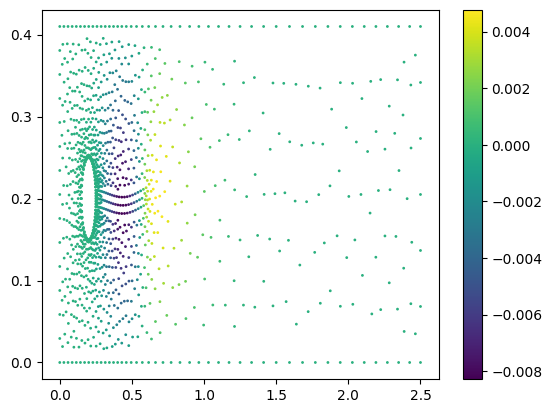

In [10]:
plt.scatter(mesh[0,:] + dis_array[time,:,0], mesh[1,:]+ dis_array[time,:,1],\
            c=dis_array[time,:,1], cmap='viridis', s=1.0)
plt.colorbar()

In [34]:
velocity = np.loadtxt('../Data/dataset/output_velocity100.csv', delimiter=',')
print(velocity.shape)

(1317, 3)


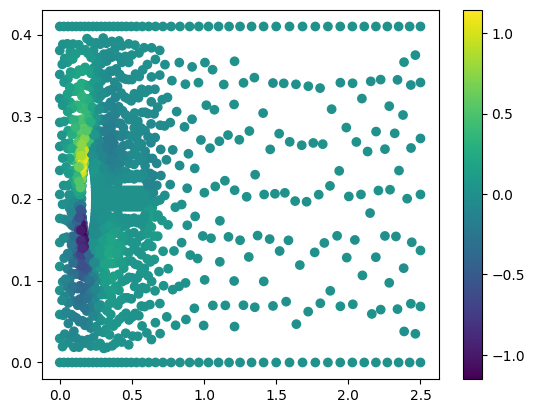

In [ ]:
plt.scatter(mesh[0,:], mesh[1,:],c=velocity[:,1], cmap='viridis')
plt.colorbar()

In [39]:
import pickle

In [36]:
ALL_dis = []
ALL_VEL = []
ALL_PRE = []

In [37]:
for i in range(5000):
    ALL_dis.append(np.loadtxt('../Data/dataset/output_displacement_'+str(i)+'.csv', delimiter=','))

In [38]:
DISPLACEMENT = np.stack(ALL_dis, axis=0 )
print(DISPLACEMENT.shape)

(5000, 1317, 3)


In [40]:
# Save the NumPy array as a pickle file
with open('displacements0-5000.pkl', 'wb') as file:
    pickle.dump(DISPLACEMENT, file)
print("NumPy array has been saved")

NumPy array has been saved as 'output.pkl'


In [41]:
for i in range(5000):
    ALL_PRE.append(np.loadtxt('../Data/dataset/output_pressure_'+str(i)+'.csv', delimiter=','))

In [42]:
PRESSURE = np.stack(ALL_PRE, axis=0 )
print(PRESSURE.shape)

(5000, 1317)


In [43]:
with open('pressures0-5000.pkl', 'wb') as file:
    pickle.dump(PRESSURE, file)
print("NumPy array has been saved")

NumPy array has been saved


In [44]:
for i in range(5000):
    ALL_VEL.append(np.loadtxt('../Data/dataset/output_velocity'+str(i)+'.csv', delimiter=','))

In [45]:
VELO = np.stack(ALL_VEL, axis=0 )
print(VELO.shape)

(5000, 1317, 3)


In [46]:
with open('velocitoes0-5000.pkl', 'wb') as file:
    pickle.dump(VELO, file)
print("NumPy array has been saved")

NumPy array has been saved


In [11]:
from data_utils.data_utils import MakserNonuniformMest, batched_masker, MaskerUniform, get_meshes
from YParams import YParams
from data_utils.data_loaders import *

In [12]:
params = YParams('./config/ssl.yaml', 'codano_gno', print_params=False)

In [13]:
grid_non, grid_uni = get_meshes(params.input_mesh_location, params.grid_size)
test_augmenter = MakserNonuniformMest(
                grid_non_uni=grid_non.clone().detach(),
                gird_uni=grid_uni.clone().detach(),
                radius=params.masking_radius,
                drop_type=params.drop_type,
                drop_pix=params.drop_pix,
                channel_aug_rate=params.channel_per,
                channel_drop_rate=params.channel_drop_per)

In [14]:
dataset = Dataset()
train, test = dataset.get_onestep_dataloader(ntrain=params.get('ntrain'),
                                                 ntest=params.get('ntest'))
normalizer = dataset.normalizer
normalizer.cuda()

Means:  tensor([ 1.5977e+00,  1.4151e-03, -3.4730e+02, -2.3491e-04,  2.0825e-04])
stds  tensor([1.4112e+00, 5.1303e-01, 1.7617e+03, 8.7147e-04, 5.4537e-03])


In [17]:
grid_non, grid_uni = get_meshes(params.input_mesh_location, params.grid_size)

test_augmenter = MakserNonuniformMest(
            grid_non_uni=grid_non.clone().detach(),
            gird_uni=grid_uni.clone().detach(),
            radius=0.08,
            drop_type=params.drop_type,
            drop_pix=params.drop_pix,
            channel_aug_rate=0.3,
            channel_drop_rate=1.0)

torch.Size([1, 1317, 5])
Maksed


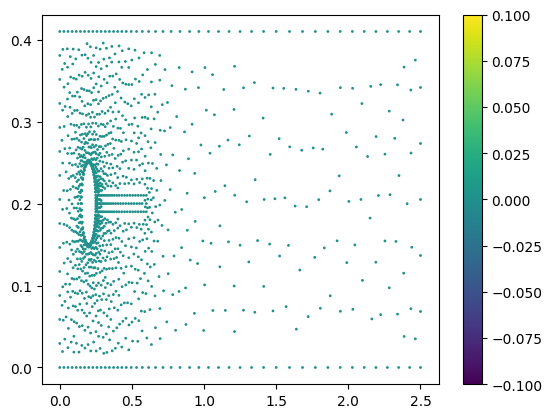

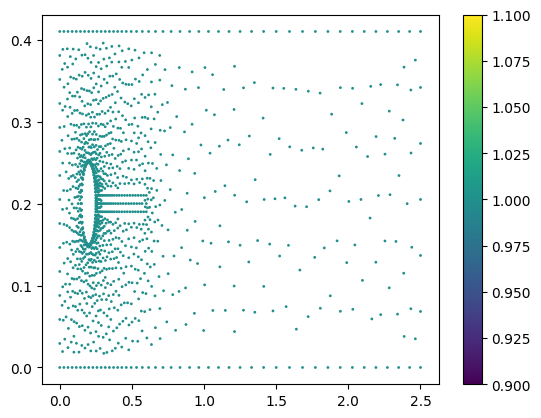

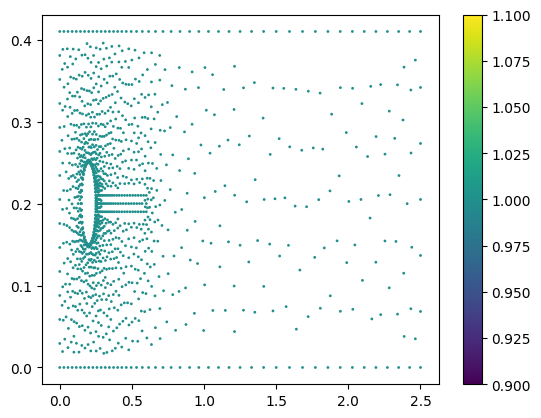

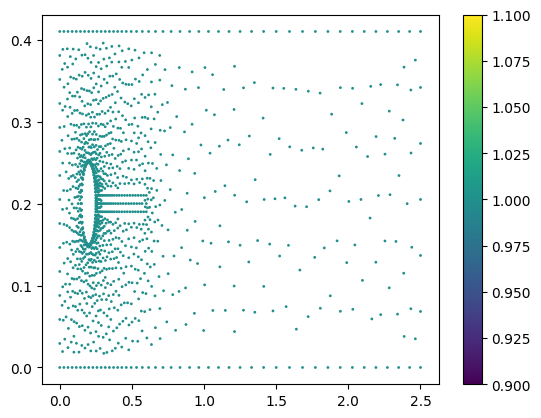

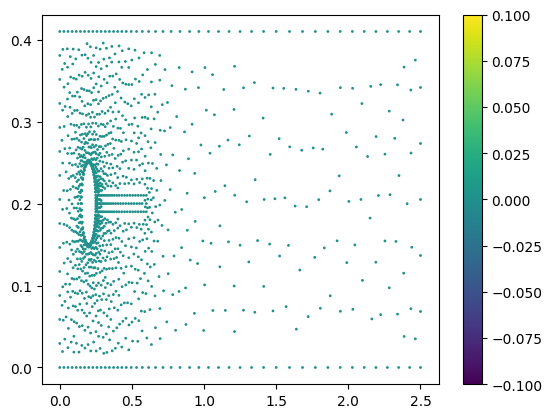

In [18]:
for x,y in train:
#     for i in [0,1,3,4,5]:
#         plt.scatter(mesh[0,:], mesh[1,:],\
#                 c=x[0,:,i].cpu(), cmap='viridis', s=1.0)
#         plt.colorbar()
#         plt.show()
    xa,y = batched_masker(x, test_augmenter)
    print(x.shape)
    print("Maksed")
    for i in range(5):
        plt.scatter(mesh[0,:], mesh[1,:],\
                c=y[0,:,i].cpu(), cmap='viridis', s=1.0)
        plt.colorbar()
        plt.show()
    break

In [23]:
y

tensor([[[0., 1., 1., 1., 1.],
         [0., 1., 1., 1., 1.],
         [0., 1., 1., 1., 1.],
         ...,
         [0., 1., 1., 1., 1.],
         [0., 1., 1., 1., 1.],
         [0., 1., 1., 1., 1.]]])